In [32]:
from typing import Tuple

import numpy as np


import time

import numpy as np

import  rigid
import tifffile
import matplotlib.pyplot as plt
import numpy as np
from caiman.mmapping import load_memmap
from pathlib import Path
from scipy.ndimage import gaussian_filter


In [2]:
# 1. load mmap
# 2. repalce z files with shifted z files
# 3. add the function into pipelne pipeline_mcorr_cnmf line 661
# 4. plot ther corrected z series

In [3]:
#  Load the movie

# mcorr_tif_path='D:/Analysis_2P/Data/Analysis/Scnn1aAi14_A2M0/01192024/run2/mesmerize/c6b67a57-09ed-497a-8d61-4e4752cc6ade/mcorr_u16.tiff'
# mcorr_tif_path='D:/Analysis_2P/Data/Scnn1aAi14_A2M0/01042024/TSeries-01042024-1531-001/TSeries-01042024-1531-001_Cycle00001_Ch1_000001.ome.tif'
# mcorr_tif_file = tifffile.TiffFile(mcorr_tif_path)
# mcorr_tif = mcorr_tif_file.asarray()
# mcorr_tif_file.close()

# zstack_tiff_file = tifffile.TiffFile("D:/Analysis_2P/Data/Scnn1aAi14_A2M0/01192024/ZSeries-01192024-1323-002/ZSeries-01192024-1323-002_Cycle00001_Ch1_000001.ome.tif")
# zstack_tiff = zstack_tiff_file.asarray()
# zstack_tiff_file.close()
# mcorr_tif.dtype, zstack_tiff.dtype




In [4]:
def compute_zpos(Zreg_path, ops, Treg_mmap_path):
    """Compute z position of frames given z-stack Zreg and Treg array.

    Parameters
    ----------
    Zreg : 3D array
        size [nplanes x Ly x Lx], z-stack
    ops : dictionary
        Parameters including "smooth_sigma", etc.
    Treg : mmap path for Tseries
        size [nFrames x Ly x Lx], registered movie

    Returns
    -------
    ops_orig
    zcorr
    """
    # Load the z-stack 
    zstack_tiff_file = tifffile.TiffFile(Zreg_path)
    Zreg = zstack_tiff_file.asarray()
    zstack_tiff_file.close()
    print(Zreg.shape, Zreg.dtype, Zreg.max(), Zreg.min())
    # flip the Zreg
    Zreg = np.flip(Zreg, axis=1)


    # load Treg_mmap_path
    mcorr_movie_16bit , dims, T = load_memmap(Treg_mmap_path)
    # Reshape the array to the desired dimensions
    Treg = np.reshape(mcorr_movie_16bit.T, [T] + list(dims), order='F')
    print(Treg.shape, Treg.dtype, Treg.max(), Treg.min())


    Ly, Lx = Treg.shape[1], Treg.shape[2]

    ops_orig = ops.copy()
    ops["nonrigid"] = False
    nplanes, zLy, zLx = Zreg.shape
    if Zreg.shape[1] > Ly or Zreg.shape[2] != Lx:
        Zreg = Zreg[:, :Ly, :Lx]

    nFrames, _, _ = Treg.shape
    zcorr = np.zeros((Zreg.shape[0], nFrames), np.float32)
    t0 = time.time()

    refAndMasks = []
    for Z in Zreg:
        if ops["1Preg"]:
            Z = Z.astype(np.float32)
            Z = Z[np.newaxis, :, :]
            if ops["pre_smooth"]:
                Z = utils.spatial_smooth(Z, int(ops["pre_smooth"]))
            Z = utils.spatial_high_pass(Z, int(ops["spatial_hp_reg"]))
            Z = Z.squeeze()

        maskMul, maskOffset = rigid.compute_masks(
            refImg=Z,
            maskSlope= 3 * ops["smooth_sigma"],
        )
        cfRefImag = rigid.phasecorr_reference(refImg=Z, smooth_sigma=ops["smooth_sigma"])
        cfRefImag = cfRefImag[np.newaxis, :, :]
        refAndMasks.append((maskMul, maskOffset, cfRefImag))

    for nfr in range(nFrames):
        data = Treg[nfr:nfr + 1]  # Get the current frame
        inds = np.array([nfr])     # Index of the current frame

        for z, ref in enumerate(refAndMasks):
            if ops["1Preg"]:
                data = data.astype(np.float32)
                if ops["pre_smooth"]:
                    data = utils.spatial_smooth(data, int(ops["pre_smooth"]))
                data = utils.spatial_high_pass(data, int(ops["spatial_hp_reg"]))

            maskMul, maskOffset, cfRefImg = ref
            cfRefImg = cfRefImg.squeeze()

            _, _, zcorr[z, inds] = rigid.phasecorr(
                data=rigid.apply_masks(data=data, maskMul=maskMul, maskOffset=maskOffset),
                cfRefImg=cfRefImg,
                maxregshift=ops["maxregshift"],
                smooth_sigma_time=ops["smooth_sigma_time"],
            )

        if nfr % 10 == 0:
            print(f"{z + 1} planes, {nfr + 1}/{nFrames} frames, {time.time() - t0:.2f} sec.")

       

    print(f"{z + 1} planes, {nFrames}/{nFrames} frames, {time.time() - t0:.2f} sec.")
    ops_orig["zcorr"] = zcorr



    # Apply Gaussian smoothing along the Z dimension
    zcorr = gaussian_filter(zcorr, sigma=[0, 1])  # Adjust sigma[0] for the desired smoothing level



    return ops_orig, zcorr


In [5]:
ops = {         
    
    'smooth_sigma': 1.15,         # Standard deviation for Gaussian smoothing of Z-stack
    '1Preg': False,              # False for two-photon data
    'pre_smooth': 0,             # Pre-smoothing is not typically used for 2P data
    'spatial_hp_reg': 42,         # High-pass filtering is not typically used for 2P data
    'spatial_taper': 40,         # Width of the taper applied to the edges of the frames
    'maxregshift': 0.1,           # Maximum allowed shift in pixels during registration
    'smooth_sigma_time': 0,      # Standard deviation for temporal smoothing of registration shifts
    'nonrigid': False,           # False for rigid registration
}

# Zreg_path=  "D:/Analysis_2P/Data/Scnn1aAi14_A2M0/01042024/ZSeries-01042024-1531-001/zstack4_shifted.tif"
Zreg_path = "D:/Analysis_2P/Data/C57_O1M2/10022023/ZSeries-10022023-1300-002/zstack4_shifted.tif"

proc_folder = Path('D:/Analysis_2P/Data/Analysis/C57_O1M2/10022023/run2/mesmerize')
mcorr_folder = '19fa5a4a-0d1d-4063-b67d-eee4a56e8a14'
mcorr_mmap = f"{mcorr_folder}-cat_tiff_bt_els__d1_765_d2_765_d3_1_order_F_frames_1600.mmap"
Treg_mmap_path = proc_folder / mcorr_folder / mcorr_mmap


In [6]:
ops_orig, zcorr = compute_zpos(Zreg_path,ops,Treg_mmap_path) 

(41, 765, 765) uint8 255 0


(1600, 765, 765) float32 65535.0 0.0
41 planes, 1/1600 frames, 6.12 sec.
41 planes, 11/1600 frames, 18.72 sec.
41 planes, 21/1600 frames, 31.17 sec.
41 planes, 31/1600 frames, 43.41 sec.
41 planes, 41/1600 frames, 55.62 sec.
41 planes, 51/1600 frames, 67.89 sec.
41 planes, 61/1600 frames, 80.29 sec.
41 planes, 71/1600 frames, 92.56 sec.
41 planes, 81/1600 frames, 104.76 sec.
41 planes, 91/1600 frames, 117.08 sec.
41 planes, 101/1600 frames, 129.44 sec.
41 planes, 111/1600 frames, 141.65 sec.
41 planes, 121/1600 frames, 153.88 sec.
41 planes, 131/1600 frames, 166.24 sec.
41 planes, 141/1600 frames, 178.45 sec.
41 planes, 151/1600 frames, 190.79 sec.
41 planes, 161/1600 frames, 203.03 sec.
41 planes, 171/1600 frames, 215.23 sec.
41 planes, 181/1600 frames, 227.57 sec.
41 planes, 191/1600 frames, 239.90 sec.
41 planes, 201/1600 frames, 252.11 sec.
41 planes, 211/1600 frames, 264.38 sec.
41 planes, 221/1600 frames, 276.69 sec.
41 planes, 231/1600 frames, 288.90 sec.
41 planes, 241/1600 fra

In [7]:
zcorr.shape

(41, 1600)

In [8]:
zcorr

array([[0.02585679, 0.02482832, 0.02521841, ..., 0.02292139, 0.02224406,
        0.02152751],
       [0.02756669, 0.0264856 , 0.02674182, ..., 0.02449491, 0.02394072,
        0.02286411],
       [0.03028276, 0.02951376, 0.02982861, ..., 0.0274436 , 0.02693955,
        0.0254084 ],
       ...,
       [0.00698613, 0.00712879, 0.00724724, ..., 0.00739247, 0.0076247 ,
        0.00760929],
       [0.00661705, 0.00683923, 0.00681382, ..., 0.00703316, 0.0069391 ,
        0.00692173],
       [0.00623324, 0.00623429, 0.00679991, ..., 0.00682262, 0.00668319,
        0.0065833 ]], dtype=float32)

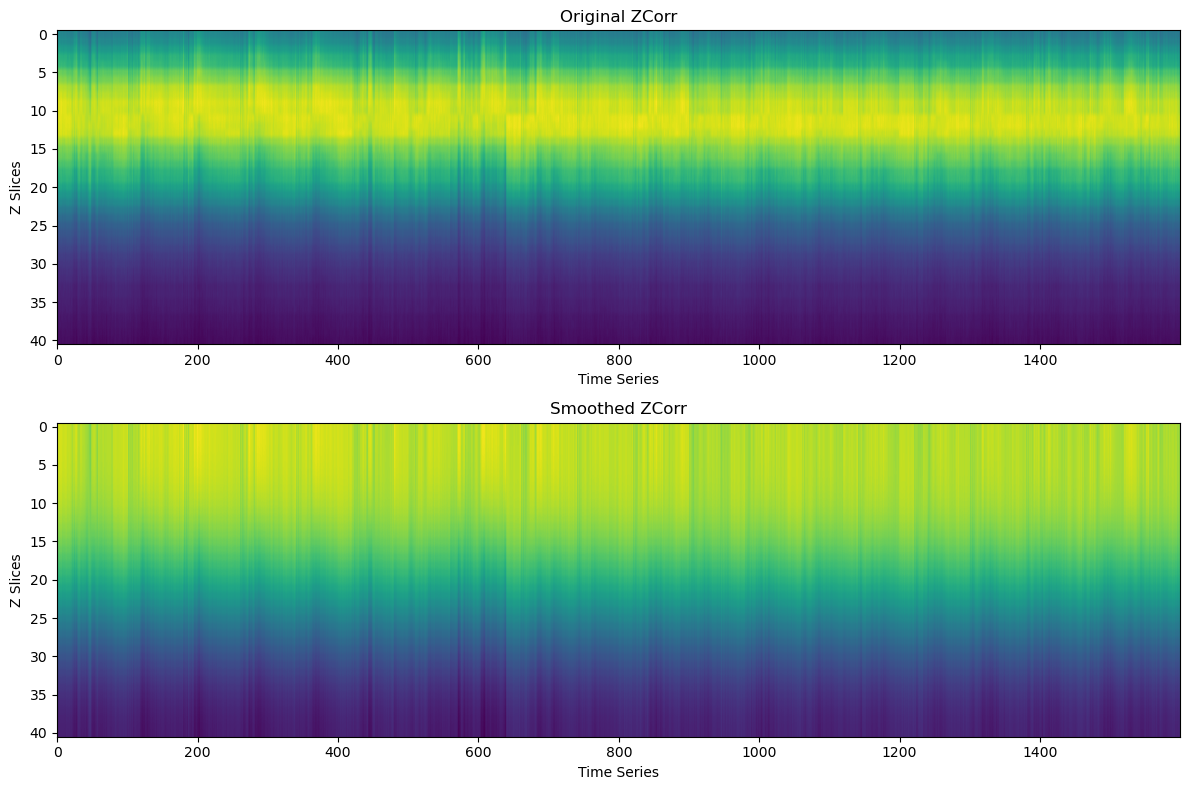

In [285]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

smoothed_zcorr = gaussian_filter(zcorr, sigma=[10, 0])

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot the original data
axes[0].imshow(zcorr, aspect='auto', cmap='viridis')
axes[0].set_title('Original ZCorr')
axes[0].set_xlabel('Time Series')
axes[0].set_ylabel('Z Slices')

# Plot the smoothed data
axes[1].imshow(smoothed_zcorr, aspect='auto', cmap='viridis')
axes[1].set_title('Smoothed ZCorr')
axes[1].set_xlabel('Time Series')
axes[1].set_ylabel('Z Slices')

plt.tight_layout()
plt.show()

In [266]:

# Apply Gaussian smoothing along the Z dimension
smoothed_zcorr = gaussian_filter(zcorr, sigma=[1,0])  # Adjust sigma[0] for the desired smoothing level


In [267]:
z_positions = np.argmax(smoothed_zcorr, axis=0)
print(z_positions)

[ 9 10 10 ... 12 12 12]


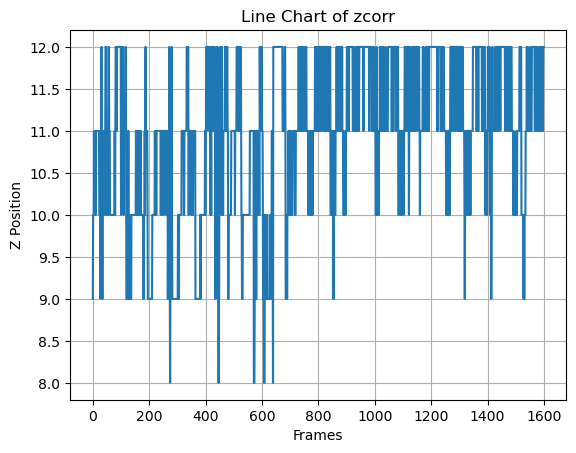

In [268]:
import matplotlib.pyplot as plt

def plot_zcorr(zcorr):
    plt.plot(zcorr)
    plt.xlabel('Frames')
    plt.ylabel('Z Position')
    plt.title('Line Chart of zcorr')
    plt.grid(True)
    plt.show()

# Example usage
plot_zcorr(z_positions)

In [269]:
zcorr

array([[0.02585679, 0.02482832, 0.02521841, ..., 0.02292139, 0.02224406,
        0.02152751],
       [0.02756669, 0.0264856 , 0.02674182, ..., 0.02449491, 0.02394072,
        0.02286411],
       [0.03028276, 0.02951376, 0.02982861, ..., 0.0274436 , 0.02693955,
        0.0254084 ],
       ...,
       [0.00698613, 0.00712879, 0.00724724, ..., 0.00739247, 0.0076247 ,
        0.00760929],
       [0.00661705, 0.00683923, 0.00681382, ..., 0.00703316, 0.0069391 ,
        0.00692173],
       [0.00623324, 0.00623429, 0.00679991, ..., 0.00682262, 0.00668319,
        0.0065833 ]], dtype=float32)

In [270]:
# compare suite2p data
import numpy as np
from scipy.io import loadmat

def load_mat_to_ndarray(file_path, variable_name):
    """
    Load a specified variable from a .mat file and convert it to a NumPy ndarray.
    
    Parameters:
    - file_path: str, the path to the .mat file.
    - variable_name: str, the name of the variable in the .mat file to convert to an ndarray.
    
    Returns:
    - ndarray: The specified variable as a NumPy ndarray.
    """
    # Load the .mat file
    data = loadmat(file_path)
    
    # Extract the specified variable
    if variable_name in data:
        ndarray = data[variable_name]
        # Check if the loaded data is structured or requires further processing
        if isinstance(ndarray, np.ndarray):
            return ndarray
        else:
            raise ValueError(f"{variable_name} is not stored as an ndarray.")
    else:
        raise KeyError(f"{variable_name} not found in the .mat file.")




In [271]:
# Usage example

file_path = "C:/Users/Kyle/Downloads/zcorr (1).mat"
ndarray = load_mat_to_ndarray(file_path,"zcorr")
print(ndarray)

[[0.02578953 0.0245498  0.02505897 ... 0.02274074 0.02202147 0.02125841]
 [0.02708661 0.02590596 0.02631152 ... 0.02416165 0.02341573 0.02267386]
 [0.03011942 0.02919449 0.02946685 ... 0.02681102 0.02643238 0.02537469]
 ...
 [0.00700971 0.00721084 0.00712228 ... 0.00741906 0.00758592 0.00754977]
 [0.00668002 0.00693061 0.00678504 ... 0.00713364 0.00684139 0.00703289]
 [0.00625208 0.00620411 0.00682357 ... 0.00697092 0.00674299 0.00679187]]


In [272]:
ndarray.shape

(41, 1600)

In [273]:
z_positions_suite2p = np.argmax(ndarray, axis=0)
print(z_positions_suite2p)

[ 9  9  9 ... 12 13 12]


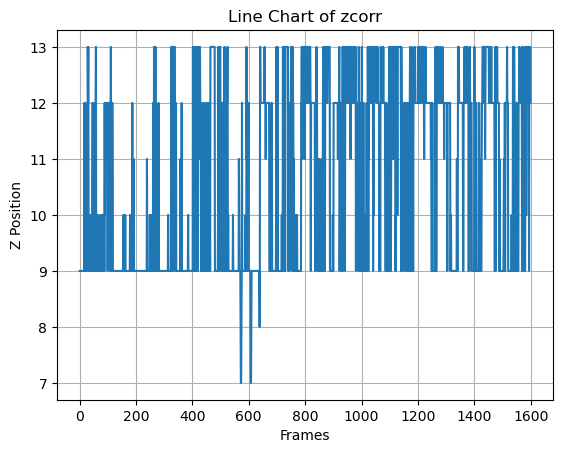

In [274]:
# Example usage
plot_zcorr(z_positions_suite2p)

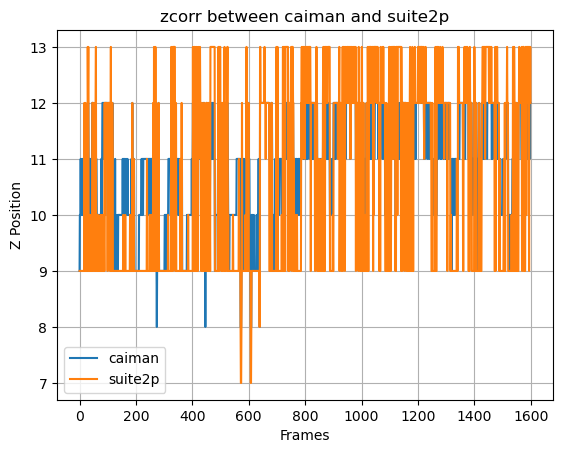

In [275]:
# plot two figures together
plt.plot(z_positions, label='caiman')
plt.plot(z_positions_suite2p, label='suite2p')
plt.xlabel('Frames') 
plt.ylabel('Z Position')
plt.title('zcorr between caiman and suite2p')
plt.legend()
plt.grid(True)
plt.show()


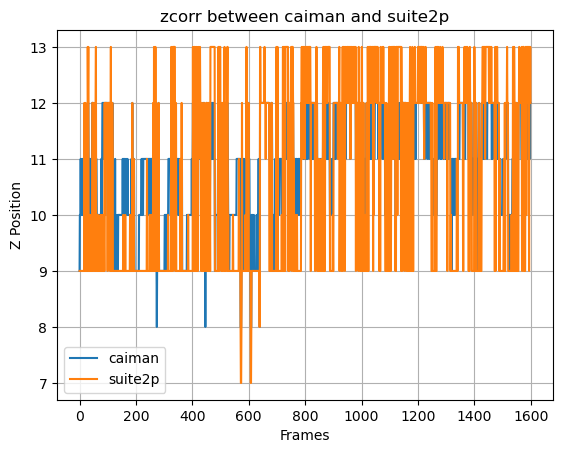

In [276]:
# plot two figures together
plt.plot(z_positions, label='caiman')
plt.plot(z_positions_suite2p, label='suite2p')
plt.xlabel('Frames') 
plt.ylabel('Z Position')
plt.title('zcorr between caiman and suite2p')
plt.legend()
plt.grid(True)
plt.show()


In [277]:
# load mat file
import numpy as np
from scipy.io import loadmat
# LOAD 

In [278]:

# 找出不同值的索引
different_indices = [i for i, (a, b) in enumerate(zip(z_positions, z_positions_suite2p)) if a != b]
print("z_positions_caiman: ", z_positions)
print("z_positions_suite2p: ", z_positions_suite2p)
print("Index of difference frames: ", different_indices)
print(len(different_indices))

z_positions_caiman:  [ 9 10 10 ... 12 12 12]
z_positions_suite2p:  [ 9  9  9 ... 12 13 12]
Index of difference frames:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 31, 32, 33, 35, 36, 37, 38, 39, 41, 42, 43, 44, 49, 50, 51, 52, 53, 54, 55, 58, 59, 60, 61, 62, 63, 64, 66, 67, 68, 69, 70, 71, 72, 73, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 90, 97, 99, 100, 103, 104, 105, 106, 108, 109, 111, 112, 114, 115, 117, 118, 126, 133, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 181, 182, 183, 184, 185, 186, 188, 189, 190, 191, 193, 194, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 25

In [279]:
import scipy.io

# Assuming z_positions and z_positions_suite2p are defined
different_indices = [i for i, (a, b) in enumerate(zip(z_positions, z_positions_suite2p)) if a != b]

# Create a dictionary to store the data
mat_data = {
    'z_positions_caiman': z_positions,
    'z_positions_suite2p': z_positions_suite2p,
    'index_of_difference_frames': different_indices
}


# Save the dictionary to a .mat file
scipy.io.savemat('difference_indices_10022023_1300_002.mat', mat_data)

print("Results have been saved to difference_indices.mat")





Results have been saved to difference_indices.mat


In [280]:
# load it back
import scipy.io
import numpy as np
mat_data = scipy.io.loadmat('difference_indices_10022023_1300_002.mat')
z_positions_caiman = mat_data['z_positions_caiman']
z_positions_suite2p = mat_data['z_positions_suite2p']

# compute the error rate between two z positions
error_rate = np.mean(z_positions_caiman != z_positions_suite2p)
print("error_rate",error_rate)

# compute the rate that the difference is within 1 frame
within_1_frame_rate = np.mean(abs(z_positions_caiman - z_positions_suite2p) > 1)
print("diff_exceed_1_frame_rate",within_1_frame_rate)


# compute the rate that the difference is within 2 frames
within_2_frames_rate = np.mean(abs(z_positions_caiman - z_positions_suite2p) > 2)
print("diff_exceed__2_frame_rate",within_2_frames_rate)



# compute the rate that the difference is within 3 frames
within_3_frames_rate = np.mean(abs(z_positions_caiman - z_positions_suite2p) > 3)
print("diff_exceed__3_frame_rate",within_3_frames_rate)


error_rate 0.679375
diff_exceed_1_frame_rate 0.301875
diff_exceed__2_frame_rate 0.009375
diff_exceed__3_frame_rate 0.0
